In [3]:
from pathlib import Path
import pygimli as pg  # Stelle sicher, dass das Modul pg importiert ist und verfügbar ist
from pygimli.physics import ert
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from datetime import datetime
import os
import numpy as np
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker
import matplotlib.ticker as mticker

from Hilfsfunktionen import T_corr_nach_Inversion
from Hilfsfunktionen import plotting_function
from Hilfsfunktionen import plotting_function_FTL

# Read data
file = "two_timesteps.ohm"
base_dir = Path("filtered_data")
data = []
for unterordner in base_dir.iterdir():
    if unterordner.is_dir():
        datei_pfad = unterordner / "two_timesteps.ohm" 
        if datei_pfad.exists():
            daten_objekt = pg.load(str(datei_pfad))
            data.append([unterordner.name, daten_objekt])
            print(f"Load data: {datei_pfad}")

# Create method manager
manager = []
for ts in data:
    manager.append(ert.ERTManager(ts[1], verbose=True))

Load data: filtered_data\240610\two_timesteps.ohm
Load data: filtered_data\240704\two_timesteps.ohm


[NbConvertApp] Converting notebook Hilfsfunktionen.ipynb to script
[NbConvertApp] Writing 24887 bytes to Hilfsfunktionen.py


In [4]:
# Time -Lapse Diffference inversion

# Lambda-Liste
lam_list_2 = np.logspace(np.log10(10), np.log10(1000), 40)

num_steps = len(manager)  # Anzahl Zeitschritte / Manager

# --- Initialisiere Container: eine Liste pro Zeitschritt (manager)
manager_list_tl = {step: [] for step in range(num_steps)}
results_tl_diff = {step: [] for step in range(num_steps)}
chi2_dict_3      = {step: [] for step in range(num_steps)}
phi_m_dict_3     = {step: [] for step in range(num_steps)}
phi_d_dict_3     = {step: [] for step in range(num_steps)}
rms_dict_3       = {step: [] for step in range(num_steps)}
rrms_dict_3      = {step: [] for step in range(num_steps)}
phi_m_zeitlich= {step: [] for step in range(num_steps)}

res0_diff=manager[0].invert(
                manager[0].data,
                quality=34,
                paraMaxCellSize=0.5,
                paraDepth=15,
                lam=10,
                dPhi=0.1
            )

# --- Schleifen: zuerst über lambda, dann über alle Zeitschritte (Time-Lapse pro lambda)
for lam_number,lam in enumerate(lam_list_2):
    for step, mgr in enumerate(manager):
        if step == 0:
            # erster Zeitschritt für dieses lambda
            res = res0_diff
            results_tl_diff[step].append(res)
            continue
        
        if step == 1:
            start_model = results_tl_diff[step-1][-1]
            data = mgr.data
            dataD = data.copy()
            dataD["rhoa"] = data["rhoa"] * manager[step-1].inv.response / manager[step-1].inv.dataVals
            dataD["err"] = np.sqrt((manager[step-1].data['err'])**2+(manager[step].data['err'])**2)
    
            manager_list_tl[step].append(ert.Manager(dataD))
            results_tl_diff[step].append(manager_list_tl[step][lam_number].invert(manager_list_tl[step][lam_number].data, quality=34,paraMaxCellSize=0.5,
                        paraDepth=15,lam=lam, dPhi= 0.1, startModel=start_model, isReference = True, verbose = True))

        if step > 1:
            start_model = results_tl_diff[step-1][-1]
            data = mgr.data
            dataD = data.copy()
            dataD["rhoa"] = data["rhoa"] * manager_list_tl[step-1][lam_number].inv.response / manager_list_tl[step-1][lam_number].inv.dataVals
            dataD["err"] = np.sqrt((manager[step-1].data['err'])**2+(manager[step].data['err'])**2)
            startmodel = manager_list_tl[step-1][lam_number].model
            manager_list_tl[step].append(ert.Manager(dataD))
            results_tl_diff[step].append(manager_list_tl[step][lam_number].invert(manager_list_tl[step][lam_number].data, quality=34,paraMaxCellSize=0.5,
                        paraDepth=15,lam=lam, dPhi= 0.1, startModel=start_model, isReference = True, verbose = True))
        # Zeitliche Roughness berechnen
        m1 = start_model                      # Schritt 1
        m2 = manager_list_tl[step][lam_number].inv.model                      # Schritt 2
        
        # falls m bereits log(ρ) wäre: die nächste Zeile weglassen!
        dlog = np.log(m2) - np.log(m1)     # Differenz in log(ρ)
        
        MT = np.sum(dlog**2)               # zeitliche Rauigkeit (L2)
        
        
        # --- Speichern: pro Zeitschritt eine Liste, Reihenfolge entspricht lam_list_2
        results_tl_diff[step].append(res)
        phi_m_zeitlich[step].append(MT)
        chi2_dict_3[step].append(manager_list_tl[step][lam_number].inv.chi2())
        phi_m_dict_3[step].append(manager_list_tl[step][lam_number].inv.phiModel())
        phi_d_dict_3[step].append(manager_list_tl[step][lam_number].inv.phiData())
        rms_dict_3[step].append(round(manager_list_tl[step][lam_number].inv.absrms(), 2))
        rrms_dict_3[step].append(round(manager_list_tl[step][lam_number].inv.relrms(), 2))


31/08/25 - 13:08:32 - pyGIMLi - INFO - Found 2 regions.
31/08/25 - 13:08:32 - pyGIMLi - INFO - (ERTModelling) Region with smallest marker (1) set to background.
31/08/25 - 13:08:33 - pyGIMLi - INFO - Found 2 regions.
31/08/25 - 13:08:33 - pyGIMLi - INFO - (ERTModelling) Region with smallest marker (1) set to background.
31/08/25 - 13:08:33 - pyGIMLi - INFO - Creating forward mesh from region infos.
31/08/25 - 13:08:33 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
31/08/25 - 13:08:34 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 8540 Cells: 16788 Boundaries: 12736
31/08/25 - 13:08:35 - pyGIMLi - INFO - Use median(data values)=106.19
31/08/25 - 13:08:35 - pyGIMLi - INFO - Created startmodel from forward operator: 3104, min/max=106.190000/106.190000
31/08/25 - 13:08:35 - pyGIMLi - INFO - Starting inversion.


fop: <pygimli.physics.ert.ertModelling.ERTModelling object at 0x00000205FE3C0270>
Data transformation: <pgcore._pygimli_.RTransLogLU object at 0x00000205FE3C04F0>
Model transformation: <pgcore._pygimli_.RTransLog object at 0x00000205FE3C03B0>
min/max (data): 21.65/1126
min/max (error): 10.1%/10.15%
min/max (start model): 106/106
--------------------------------------------------------------------------------
inv.iter 0 ... chi² =   79.01
--------------------------------------------------------------------------------
inv.iter 1 ... chi² =   15.31 (dPhi = 76.83%) lam: 10.0
--------------------------------------------------------------------------------
inv.iter 2 ... chi² =    6.63 (dPhi = 47.62%) lam: 10.0
--------------------------------------------------------------------------------
inv.iter 3 ... chi² =    5.73 (dPhi = 7.02%) lam: 10.0
--------------------------------------------------------------------------------
inv.iter 4 ... chi² =    5.71 (dPhi = 0.25%) lam: 10.0
------------

31/08/25 - 13:11:02 - pyGIMLi - INFO - Found 2 regions.



################################################################################
#                Abort criterion reached: dPhi = 0.04 (< 0.1%)                 #
################################################################################


31/08/25 - 13:11:02 - pyGIMLi - INFO - (ERTModelling) Region with smallest marker (1) set to background.
31/08/25 - 13:11:02 - pyGIMLi - INFO - Found 2 regions.
31/08/25 - 13:11:02 - pyGIMLi - INFO - (ERTModelling) Region with smallest marker (1) set to background.
31/08/25 - 13:11:03 - pyGIMLi - INFO - Creating forward mesh from region infos.
31/08/25 - 13:11:03 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
31/08/25 - 13:11:03 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 8540 Cells: 16788 Boundaries: 12736
31/08/25 - 13:11:03 - pyGIMLi - INFO - Starting inversion.


...

fop: <pygimli.physics.ert.ertModelling.ERTModelling object at 0x00000205FE431E90>
Data transformation: <pgcore._pygimli_.RTransLogLU object at 0x00000205FE431D50>
Model transformation: <pgcore._pygimli_.RTransLog object at 0x00000205FE449CB0>
min/max (data): 14.78/866
min/max (error): 13.33%/13.38%
min/max (start model): 10.09/3556
--------------------------------------------------------------------------------
inv.iter 0 ... chi² =    3.14
--------------------------------------------------------------------------------
inv.iter 1 ... chi² =    2.81 (dPhi = 6.82%) lam: 789.7
--------------------------------------------------------------------------------
inv.iter 2 ... chi² =    2.81 (dPhi = 0.00%) lam: 789.7
--------------------------------------------------------------------------------
inv.iter 3 ... chi² =    2.81 (dPhi = -0.00%) lam: 789.7
################################################################################
#                Abort criterion reached: dPhi = -0.0 (< 0.1%)

31/08/25 - 14:05:16 - pyGIMLi - INFO - Found 2 regions.
31/08/25 - 14:05:16 - pyGIMLi - INFO - (ERTModelling) Region with smallest marker (1) set to background.
31/08/25 - 14:05:16 - pyGIMLi - INFO - Found 2 regions.
31/08/25 - 14:05:16 - pyGIMLi - INFO - (ERTModelling) Region with smallest marker (1) set to background.
31/08/25 - 14:05:16 - pyGIMLi - INFO - Creating forward mesh from region infos.
31/08/25 - 14:05:16 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
31/08/25 - 14:05:17 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 8540 Cells: 16788 Boundaries: 12736
31/08/25 - 14:05:17 - pyGIMLi - INFO - Starting inversion.
31/08/25 - 14:05:17 - pyGIMLi - INFO - Setting starting model as reference!


fop: <pygimli.physics.ert.ertModelling.ERTModelling object at 0x00000205FE449940>
Data transformation: <pgcore._pygimli_.RTransLogLU object at 0x00000205FE44A0C0>
Model transformation: <pgcore._pygimli_.RTransLog object at 0x00000205FE44A020>
min/max (data): 14.78/866
min/max (error): 13.33%/13.38%
min/max (start model): 10.09/3556
--------------------------------------------------------------------------------
inv.iter 0 ... chi² =    3.14
--------------------------------------------------------------------------------
inv.iter 1 ... chi² =    2.83 (dPhi = 6.39%) lam: 888.6
--------------------------------------------------------------------------------
inv.iter 2 ... chi² =    2.83 (dPhi = 0.00%) lam: 888.6
--------------------------------------------------------------------------------
inv.iter 3 ... chi² =    2.83 (dPhi = -0.00%) lam: 888.6
################################################################################
#                Abort criterion reached: dPhi = -0.0 (< 0.1%)

31/08/25 - 14:07:06 - pyGIMLi - INFO - Found 2 regions.
31/08/25 - 14:07:06 - pyGIMLi - INFO - (ERTModelling) Region with smallest marker (1) set to background.
31/08/25 - 14:07:06 - pyGIMLi - INFO - Found 2 regions.
31/08/25 - 14:07:06 - pyGIMLi - INFO - (ERTModelling) Region with smallest marker (1) set to background.
31/08/25 - 14:07:06 - pyGIMLi - INFO - Creating forward mesh from region infos.
31/08/25 - 14:07:07 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
31/08/25 - 14:07:07 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 8540 Cells: 16788 Boundaries: 12736
31/08/25 - 14:07:07 - pyGIMLi - INFO - Starting inversion.
31/08/25 - 14:07:07 - pyGIMLi - INFO - Setting starting model as reference!


fop: <pygimli.physics.ert.ertModelling.ERTModelling object at 0x00000205FE44A200>
Data transformation: <pgcore._pygimli_.RTransLogLU object at 0x00000205FE432070>
Model transformation: <pgcore._pygimli_.RTransLog object at 0x00000205FE449E40>
min/max (data): 14.78/866
min/max (error): 13.33%/13.38%
min/max (start model): 10.09/3556
--------------------------------------------------------------------------------
inv.iter 0 ... chi² =    3.14
--------------------------------------------------------------------------------
inv.iter 1 ... chi² =    2.85 (dPhi = 6.00%) lam: 1000.0
--------------------------------------------------------------------------------
inv.iter 2 ... chi² =    2.85 (dPhi = 0.00%) lam: 1000.0
--------------------------------------------------------------------------------
inv.iter 3 ... chi² =    2.85 (dPhi = -0.00%) lam: 1000.0
################################################################################
#                Abort criterion reached: dPhi = -0.0 (< 0.

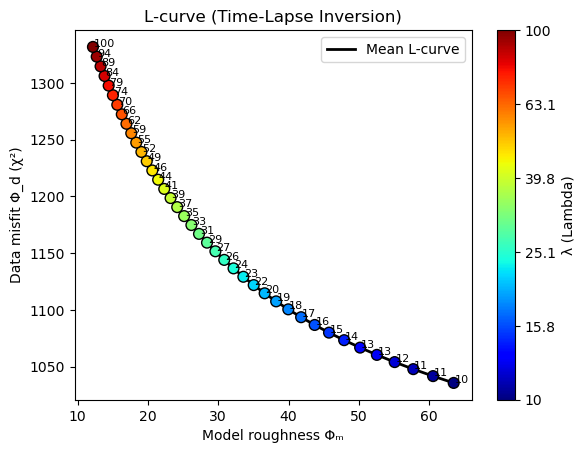

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker


# --- Mittelkurve als rote Linie
plt.plot(phi_m_zeitlich[1], phi_d_dict_3[1], color='black', linewidth=2, label='Mean L-curve')

# --- Punkte einfärben nach lam_list_2
sc = plt.scatter(phi_m_zeitlich[1], phi_d_dict_3[1], 
                 c=lam_list_2,
                 cmap='jet',
                 norm=mcolors.LogNorm(vmin=min(lam_list_2), vmax=max(lam_list_2)),
                 s=60,
                 edgecolor='black',
                 zorder=3)

# --- Lambda-Werte an die Punkte schreiben
for lam, x, y in zip(lam_list_2, phi_m_zeitlich[1], phi_d_dict_3[1]):
    plt.text(x+0.1, y+0.1, f"{lam:.0f}", fontsize=8)

# --- Farbskala hinzufügen
cbar = plt.colorbar(sc)
cbar.set_label("λ (Lambda)")

num_ticks = 6
tick_values = np.logspace(np.log10(min(lam_list_2)), np.log10(max(lam_list_2)), num=num_ticks)
cbar.locator = mticker.FixedLocator(tick_values)
cbar.ax.set_yticklabels([f"{val:.3g}" for val in tick_values])
cbar.ax.minorticks_off()

# --- Achsenbeschriftung und Titel
plt.xlabel("Model roughness Φₘ")
plt.ylabel("Data misfit Φ_d (χ²)")
plt.title("L-curve (Time-Lapse Inversion)")
plt.legend()
plt.savefig('./L_curves_Difference/L-Curve_zwei_Zeitschritte_neuerFehler_2.png', bbox_inches = 'tight', dpi=300)
np.save('./L_curves_Difference/L-Curve_zwei_Zeitschritte_phi_m_mean_neuerFehler_2.npy', phi_m_zeitlich[1])
np.save('./L_curves_Difference/L-Curve_zwei_Zeitschritte_phi_d_mean_neuerFehler_2.npy', phi_d_dict_3[1])
np.save('./L_curves_Difference/L-Curve_zwei_Zeitschritte_lam_list_neuerFehler_2.npy', lam_list_2)
plt.show()


Optimales λ: 28.90275758025849


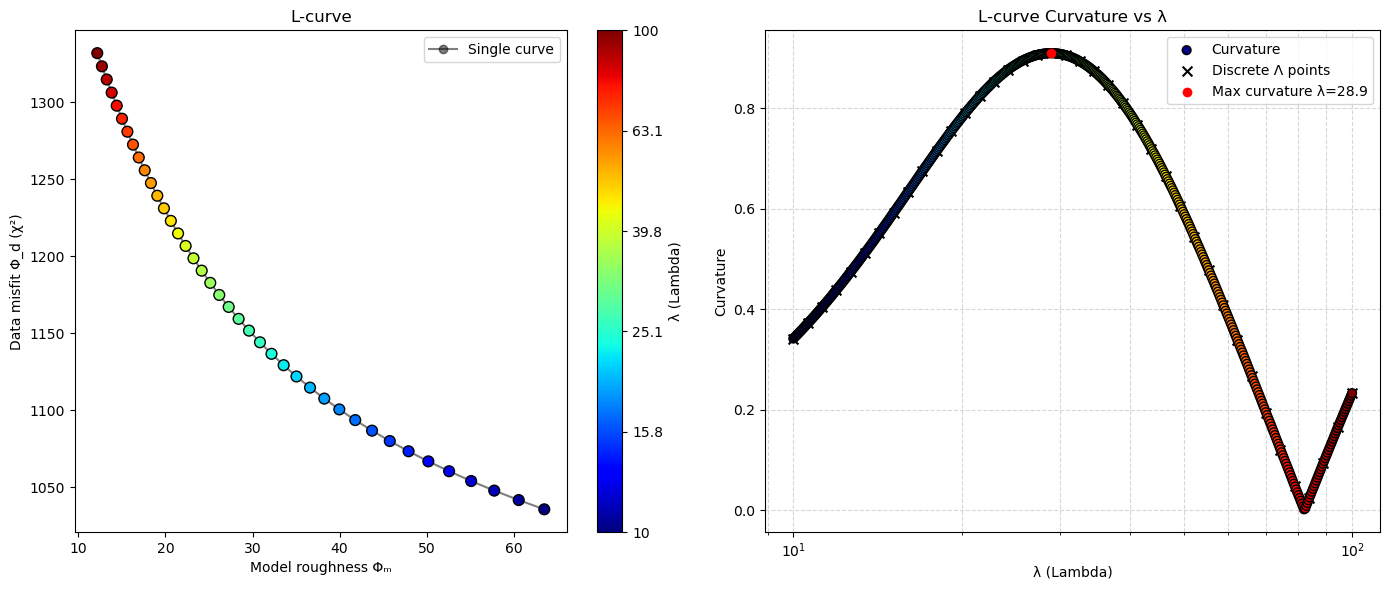

In [16]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import UnivariateSpline, interp1d
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker

spline_s = 0.001  # Smoothing factor

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,6))

# ==========================
# LINKER PLOT: L-Curve (eine Kurve)
# ==========================
ax1.plot(phi_m_zeitlich[1], phi_d_dict_3[1], color='black', marker='o', alpha=0.5)

sc = ax1.scatter(phi_m_zeitlich[1], phi_d_dict_3[1],
                 c=lam_list_2,
                 cmap='jet',
                 norm=mcolors.LogNorm(vmin=min(lam_list_2), vmax=max(lam_list_2)),
                 s=60,
                 edgecolor='black',
                 zorder=3)

cbar = fig.colorbar(sc, ax=ax1)
cbar.set_label("λ (Lambda)")
num_ticks = 6
tick_values = np.logspace(np.log10(min(lam_list_2)), np.log10(max(lam_list_2)), num=num_ticks)
cbar.locator = mticker.FixedLocator(tick_values)
cbar.ax.set_yticklabels([f"{val:.3g}" for val in tick_values])
cbar.ax.minorticks_off()

ax1.set_xlabel("Model roughness Φₘ")
ax1.set_ylabel("Data misfit Φ_d (χ²)")
ax1.set_title("L-curve")
ax1.legend(['Single curve'])

# ==========================
# RECHTER PLOT: Krümmung
# ==========================
# Normieren
x = (phi_m_zeitlich[1] - np.min(phi_m_zeitlich[1])) / (np.max(phi_m_zeitlich[1]) - np.min(phi_m_zeitlich[1]))
y = (phi_d_dict_3[1] - np.min(phi_d_dict_3[1])) / (np.max(phi_d_dict_3[1]) - np.min(phi_d_dict_3[1]))
t = np.arange(len(x))

# Spline
spl_x = UnivariateSpline(t, x, k=3, s=spline_s*len(t))
spl_y = UnivariateSpline(t, y, k=3, s=spline_s*len(t))

t_fine = np.linspace(t[0], t[-1], 500)
dx, ddx = spl_x.derivative(1)(t_fine), spl_x.derivative(2)(t_fine)
dy, ddy = spl_y.derivative(1)(t_fine), spl_y.derivative(2)(t_fine)

curv = np.abs(dx*ddy - dy*ddx) / (dx**2 + dy**2)**1.5

# Lambda fein interpolieren
lam_f = interp1d(t, lam_list_2, kind='linear')
lam_fine = lam_f(t_fine)

# Maximalpunkt
idx_opt = np.argmax(curv)
lam_opt = lam_fine[idx_opt]
print("Optimales λ:", lam_opt)

# Plot Krümmung farbig nach Lambda
sc2 = ax2.scatter(lam_fine, curv,
                  c=lam_fine,
                  cmap='jet',
                  norm=mcolors.LogNorm(vmin=min(lam_list_2), vmax=max(lam_list_2)),
                  s=40,
                  edgecolor='black',
                  zorder=3,
                  label='Curvature')

# Diskrete Lambda-Punkte als Kreuze
dx_disc, ddx_disc = spl_x.derivative(1)(t), spl_x.derivative(2)(t)
dy_disc, ddy_disc = spl_y.derivative(1)(t), spl_y.derivative(2)(t)
curv_disc = np.abs(dx_disc*ddy_disc - dy_disc*ddx_disc) / (dx_disc**2 + dy_disc**2)**1.5
ax2.scatter(lam_list_2, curv_disc, color='black', marker='x', s=50, label='Discrete Λ points')

# Maximalpunkt
ax2.scatter(lam_opt, curv[idx_opt], color='red', label=f'Max curvature λ={lam_opt:.3g}', zorder=5)

ax2.set_xscale('log')
ax2.set_xlabel('λ (Lambda)')
ax2.set_ylabel('Curvature')
ax2.set_title('L-curve Curvature vs λ')
ax2.legend()
ax2.grid(True, which='both', ls='--', alpha=0.5)

plt.tight_layout()
plt.show()


In [6]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import UnivariateSpline
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
from matplotlib.ticker import FuncFormatter

def plot_l_curve(phi_m_list, phi_d_list, lam_list, spline_s=0.001, fontsize=14, save_path=None):
    """
    L-Curve Plot mit Curvature und Maximum Curvature Annotation.

    Parameters:
    -----------
    phi_m_list : array-like
        Liste der Modell-Roughness-Werte (Φₘ).
    phi_d_list : array-like
        Liste der Daten-Misfit-Werte (Φ_d).
    lam_list : array-like
        Liste der Regularisierungsparameter λ.
    spline_s : float
        Glättungsfaktor für UnivariateSpline (default=0.001).
    fontsize : int
        Schriftgröße für Achsen, Titel, Legende und Annotation.
    """
    fig, ax1 = plt.subplots(1, 1, figsize=(8,6))

    # ==========================
    # L-Curve Plot
    # ==========================
    ax1.plot(phi_m_list, phi_d_list, color='black', marker='o', alpha=0.5, linestyle='')

    sc = ax1.scatter(phi_m_list, phi_d_list,
                     c=lam_list,
                     cmap='jet',
                     norm=mcolors.LogNorm(vmin=min(lam_list), vmax=max(lam_list)),
                     s=60,
                     edgecolor='black',
                     zorder=3)

    cbar = fig.colorbar(sc, ax=ax1)
    cbar.set_label("Regularization parameter λ", fontsize=fontsize)
    num_ticks = 6
    tick_values = np.logspace(np.log10(min(lam_list)), np.log10(max(lam_list)), num=num_ticks)
    cbar.locator = mticker.FixedLocator(tick_values)
    # Neue Formatierung für normale Zahlen
    cbar.ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{int(x)}'))
    
    cbar.ax.tick_params(labelsize=fontsize)
    cbar.ax.minorticks_off()

    ax1.set_xlabel("Temporal model roughness $Φ_m$", fontsize=fontsize)
    ax1.set_ylabel("Data misfit $Φ_d$ ", fontsize=fontsize)
    ax1.set_title("L-curve difference inversion", fontsize=fontsize+2)

    # Tick-Labels größer machen
    ax1.tick_params(axis='both', labelsize=fontsize)

    # ==========================
    # Krümmung berechnen
    # ==========================
    x = (phi_m_list - np.min(phi_m_list)) / (np.max(phi_m_list) - np.min(phi_m_list))
    y = (phi_d_list - np.min(phi_d_list)) / (np.max(phi_d_list) - np.min(phi_d_list))
    t = np.arange(len(x))

    spl_x = UnivariateSpline(t, x, k=3, s=spline_s*len(t))
    spl_y = UnivariateSpline(t, y, k=3, s=spline_s*len(t))

    dx_disc, ddx_disc = spl_x.derivative(1)(t), spl_x.derivative(2)(t)
    dy_disc, ddy_disc = spl_y.derivative(1)(t), spl_y.derivative(2)(t)
    curv_disc = np.abs(dx_disc*ddy_disc - dy_disc*ddx_disc) / (dx_disc**2 + dy_disc**2)**1.5

    # ==========================
    # Zweite Achse für Curvature ohne Beschriftung
    # ==========================
    ax1_curv = ax1.twinx()
    ax1_curv.set_ylabel('')               
    ax1_curv.set_yticklabels([])          
    ax1_curv.tick_params(axis='y', length=5)  

    # Kreuze auf Curvature-Höhe, letzte 10 Punkte weggeschnitten
    phi_m_plot = phi_m_list[:-10]
    curv_plot = curv_disc[:-10]

    ax1_curv.scatter(phi_m_plot, curv_plot,
                     s=60,
                     marker='x',
                     color='black')

    # ==========================
    # Eine gemeinsame Legende (Kreise + Kreuze)
    # ==========================
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', label='L-Curve', markerfacecolor='black', markersize=8, alpha=0.5, linestyle='None'),
        Line2D([0], [0], marker='x', color='black', label='Curvature', markersize=8, linestyle='None')
    ]
    ax1.legend(handles=legend_elements, loc='upper right', fontsize=fontsize)

    # ==========================
    # Maximalpunkt markieren mit Pfeil von rechts oben
    # ==========================
    idx_max_curv = np.argmax(curv_plot)
    phi_m_max = phi_m_plot[idx_max_curv]
    curv_max = curv_plot[idx_max_curv]
    lam_max = lam_list[idx_max_curv]

    ax1_curv.annotate(f"Maximum curvature\nat λ={lam_max:.3g}",
                     xy=(phi_m_max+2, curv_max),
                     xytext=(phi_m_max + 30, curv_max*0.81),
                     arrowprops=dict(facecolor='black', arrowstyle="->"),
                     ha='center',
                     color='black',
                     fontsize=fontsize)
    #
    plt.tight_layout()
    # ==========================
    # Optional speichern
    # ==========================
    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Figure saved to {save_path}")

    plt.show()


Figure saved to ./L_curves_Difference/L-Curve_zwei_Zeitschritte_gute_Darstellung_2_groesser_neu.png


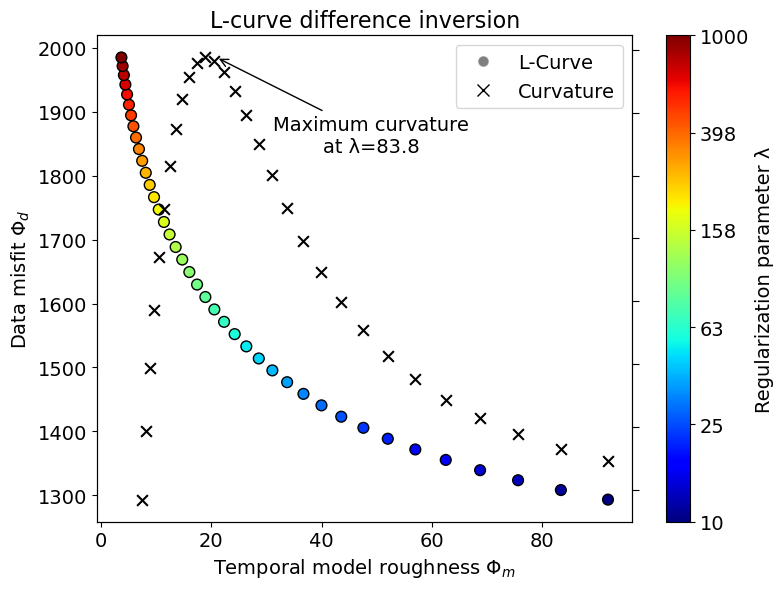

In [7]:
plot_l_curve(phi_m_zeitlich[1], phi_d_dict_3[1], lam_list_2, spline_s=0.001, fontsize=14, save_path='./L_curves_Difference/L-Curve_zwei_Zeitschritte_gute_Darstellung_2_groesser_neu.png')

#np.save('./L_curves_Reference/L-Curve_zwei_Zeitschritte_phi_m_mean_new_2.npy', phi_m_dict_3[1])
#np.save('./L_curves_Reference/L-Curve_zwei_Zeitschritte_phi_d_mean_new_2.npy', phi_d_dict_3[1])
#np.save('./L_curves_Reference/L-Curve_zwei_Zeitschritte_lam_list_new_2.npy', lam_list_2)